In [ ]:
pip install opendatasets --quiet

In [ ]:
import os
import matplotlib
import opendatasets as od
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline

sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [ ]:
import zipfile

with zipfile.ZipFile('/content/rossmann-store-sales.zip', 'r') as zip_ref:
    zip_ref.extractall('./')

In [ ]:
ross_df=pd.read_csv("/content/train.csv", low_memory=False)
ross_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [ ]:
store_df=pd.read_csv("/content/store.csv")
store_df.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


We can merge the two data frames to get a richer set of features for each row of the training set.

In [ ]:
merged_df = ross_df.merge(store_df, how='left', on='Store')
merged_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

In [ ]:
merged_df.isna().sum()

,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0
StoreType,0


In [ ]:
round(merged_df.describe().T, 2)

,count,mean,std,min,25%,50%,75%,max
Store,1017209.0,558.43,321.91,1.0,280.0,558.0,838.0,1115.0
DayOfWeek,1017209.0,4.00,2.00,1.0,2.0,4.0,6.0,7.0
Sales,1017209.0,5773.82,3849.93,0.0,3727.0,5744.0,7856.0,41551.0
Customers,1017209.0,633.15,464.41,0.0,405.0,609.0,837.0,7388.0
Open,1017209.0,0.83,0.38,0.0,1.0,1.0,1.0,1.0
Promo,1017209.0,0.38,0.49,0.0,0.0,0.0,1.0,1.0
SchoolHoliday,1017209.0,0.18,0.38,0.0,0.0,0.0,0.0,1.0
CompetitionDistance,1014567.0,5430.09,7715.32,20.0,710.0,2330.0,6890.0,75860.0
CompetitionOpenSinceMonth,693861.0,7.22,3.21,1.0,4.0,8.0,10.0,12.0
CompetitionOpenSinceYear,693861.0,2008.69,5.99,1900.0,2006.0,2010.0,2013.0,2015.0


In [ ]:
merged_df.duplicated().sum()

np.int64(0)

In [ ]:
test_df = pd.read_csv('/content/test.csv')

In [ ]:
merged_test_df = test_df.merge(store_df, how='left', on='Store')

In [ ]:
merged_test_df

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,1,4,2015-09-17,1.0,1,0,0,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,3,4,2015-09-17,1.0,1,0,0,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
2,3,7,4,2015-09-17,1.0,1,0,0,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
3,4,8,4,2015-09-17,1.0,1,0,0,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN
4,5,9,4,2015-09-17,1.0,1,0,0,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41083,41084,1111,6,2015-08-01,1.0,0,0,0,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
41084,41085,1112,6,2015-08-01,1.0,0,0,0,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
41085,41086,1113,6,2015-08-01,1.0,0,0,0,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
41086,41087,1114,6,2015-08-01,1.0,0,0,0,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


# Parsing Date Columns

In [ ]:
merged_df['Date'] = pd.to_datetime(merged_df.Date)

In [ ]:
merged_test_df['Date'] = pd.to_datetime(merged_test_df.Date)

In [ ]:
merged_df.Date.min(), merged_df.Date.max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2015-07-31 00:00:00'))

In [ ]:
merged_test_df.Date.min(), merged_test_df.Date.max()

(Timestamp('2015-08-01 00:00:00'), Timestamp('2015-09-17 00:00:00'))

### Exploratory Data Analysis and Visualization

Objectives of exploratory data analysis:

- Study the distributions of individual columns (uniform, normal, exponential)
- Detect anomalies or errors in the data (e.g. missing/incorrect values)
- Study the relationship of target column with other columns (linear, non-linear etc.)
- Gather insights about the problem and the dataset
- Come up with ideas for preprocessing and feature engineering



<Axes: xlabel='Sales', ylabel='Count'>

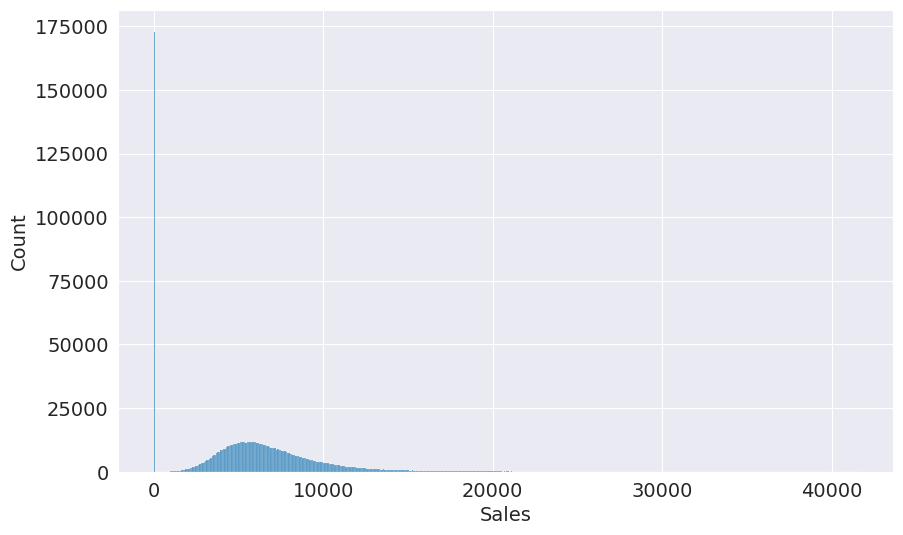

In [ ]:
sns.histplot(data=merged_df, x='Sales')

In [ ]:
merged_df.Open.value_counts()

,count
Open,
1,844392
0,172817


Since the stores were not opened on a particular day, hence it does not contribute to predicting the future sales.

In [ ]:
merged_df.Sales.value_counts()[0] # [0] accesses the count of sales that are 0

np.int64(172871)

In [ ]:
merged_df[merged_df.Sales != 0].shape[0]

844338

In [ ]:
merged_df = merged_df[merged_df['Open']==1].copy()

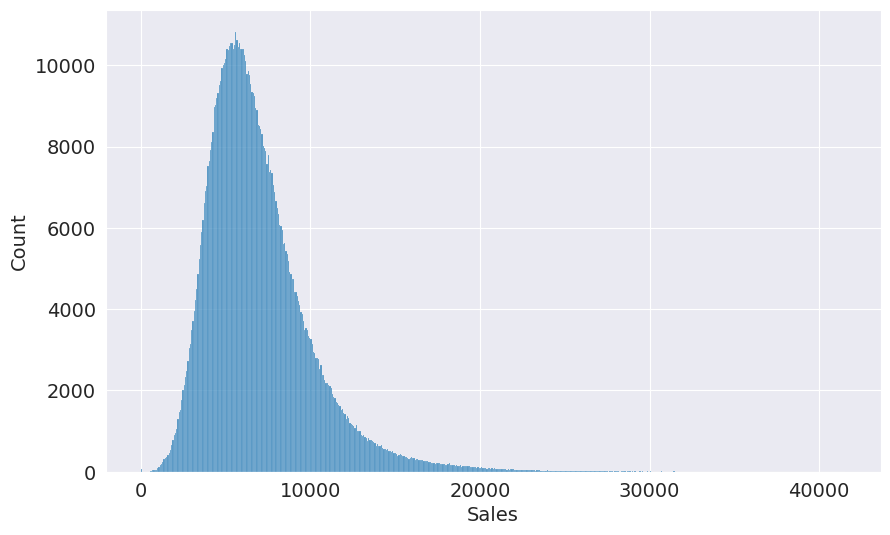

In [ ]:
sns.histplot(data=merged_df, x='Sales');

Let's explore some other columns

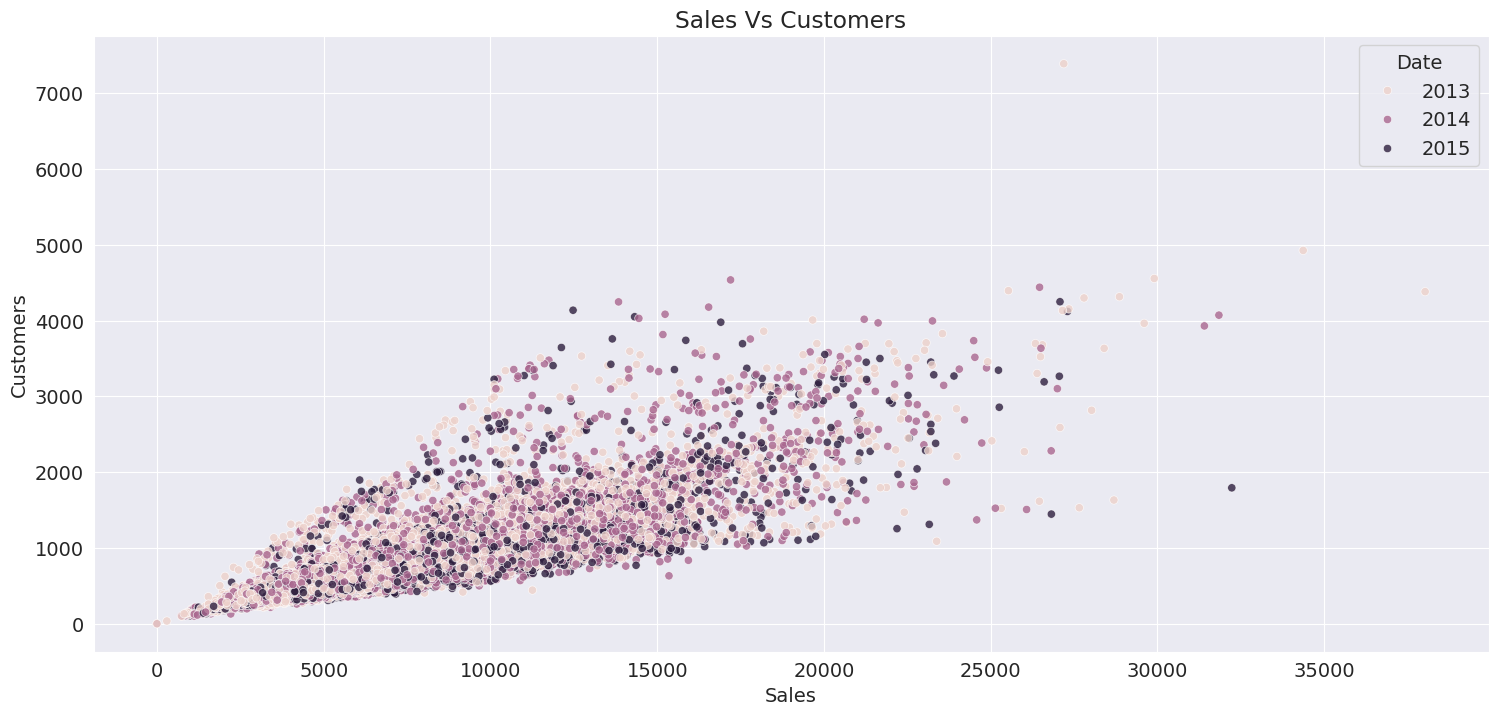

In [ ]:
plt.figure(figsize=(18,8))
temp_df = merged_df.sample(40000)
sns.scatterplot(x=temp_df.Sales, y=temp_df.Customers, hue=temp_df.Date.dt.year, alpha=0.8)
plt.title("Sales Vs Customers")
plt.show()

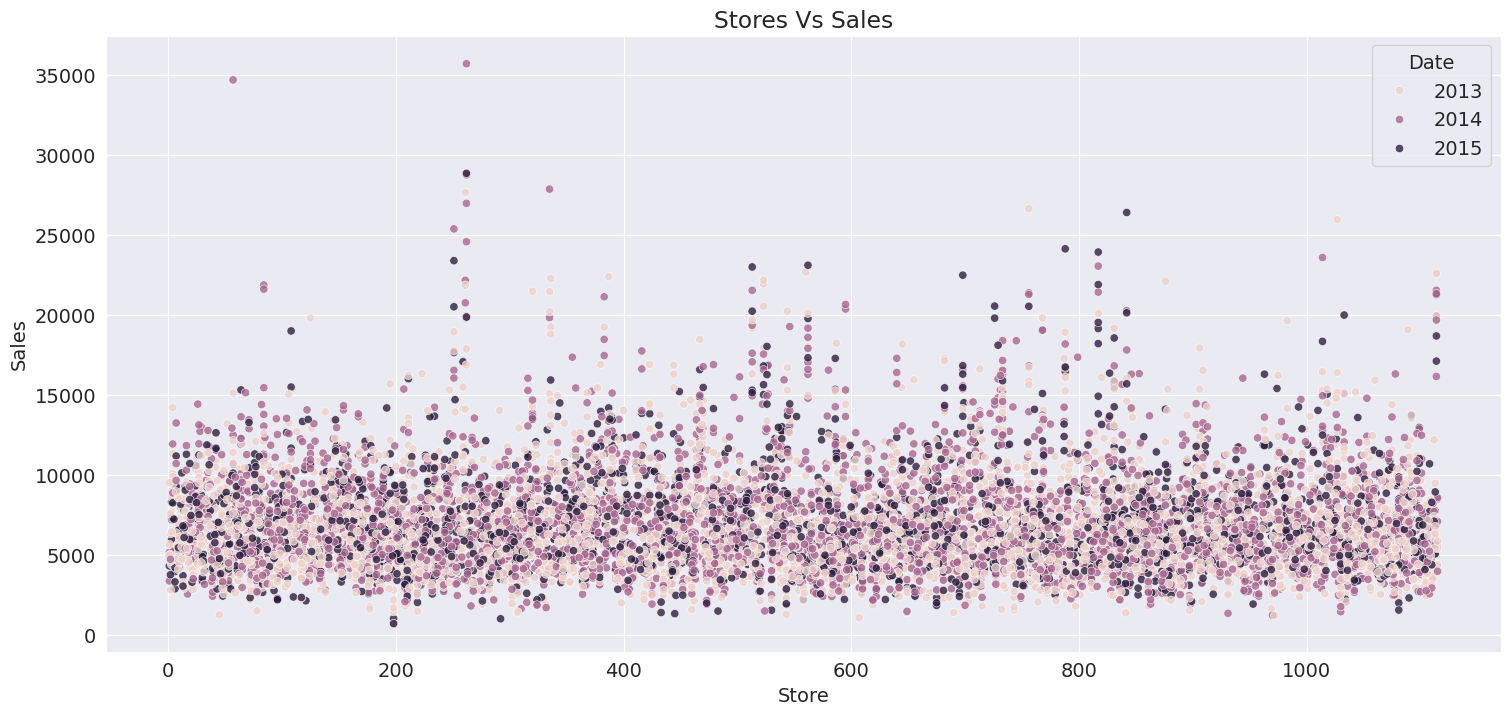

In [ ]:
plt.figure(figsize=(18,8))
temp_df = merged_df.sample(10000)
sns.scatterplot(x=temp_df.Store, y=temp_df.Sales, hue=temp_df.Date.dt.year, alpha=0.8)
plt.title("Stores Vs Sales")
plt.show()

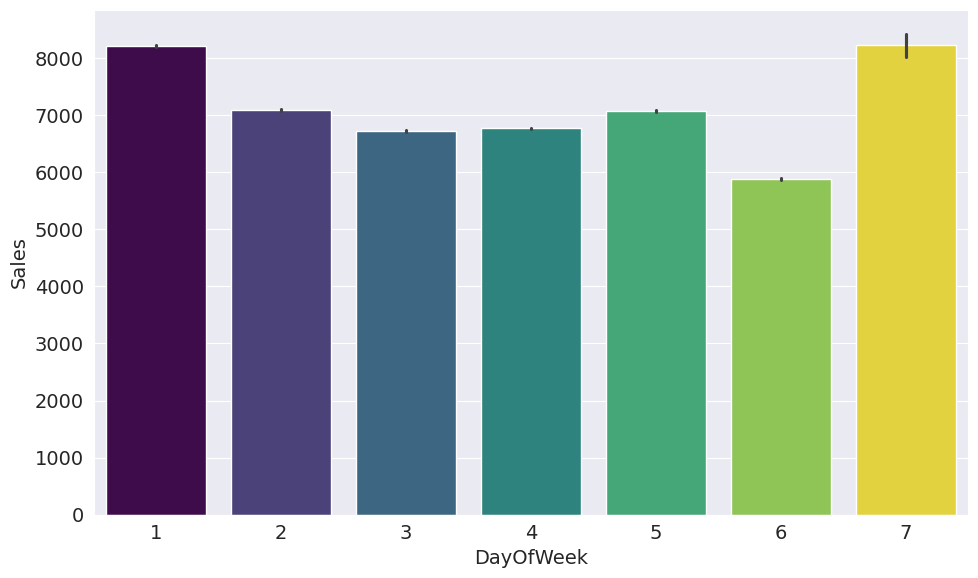

In [ ]:
sns.barplot(data=merged_df, x='DayOfWeek', y='Sales', hue='DayOfWeek', palette='viridis', legend=False)
plt.tight_layout()

<Axes: xlabel='Promo', ylabel='Sales'>

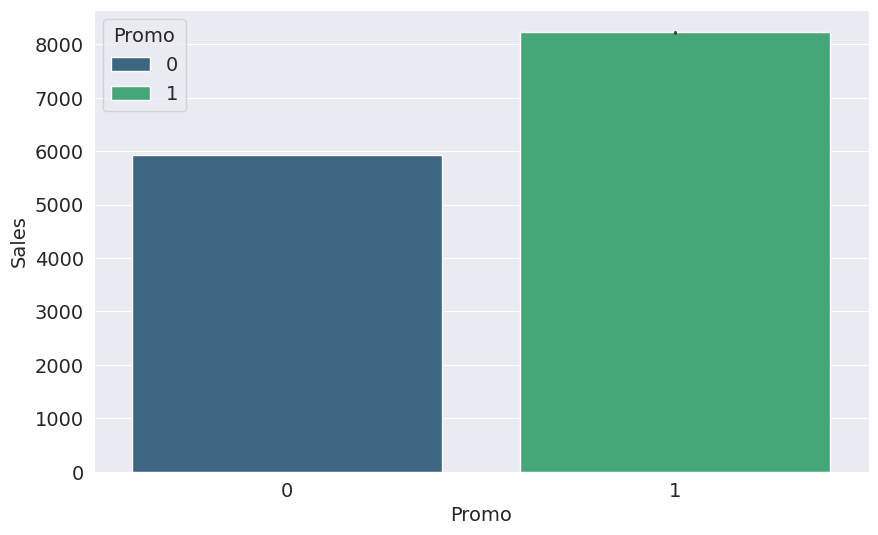

In [ ]:
sns.barplot(data=merged_df, x='Promo', y='Sales', hue='Promo', palette= 'viridis')

In [ ]:
merged_df.select_dtypes(include=np.number).corr()['Sales'].sort_values(ascending=False)

,Sales
Sales,1.000000
Customers,0.823597
Promo,0.368145
Promo2SinceWeek,0.095311
SchoolHoliday,0.038617
CompetitionOpenSinceYear,0.016101
Store,0.007710
Promo2SinceYear,-0.034713
CompetitionDistance,-0.036396
CompetitionOpenSinceMonth,-0.043489


### Feature Engineering

Feature engineer is the process of creating new features (columns) by transforming/combining existing features or by incorporating data from external sources.


For example, here are some features that can be extracted from the "Date" column:

1. Day of week
2. Day or month
3. Month
4. Year
5. Weekend/Weekday
6. Month/Quarter End


In [ ]:
merged_df['Day'] = merged_df.Date.dt.day
merged_df['Month'] = merged_df.Date.dt.month
merged_df['Year'] = merged_df.Date.dt.year

In [ ]:
merged_test_df['Day'] = merged_test_df.Date.dt.day
merged_test_df['Month'] = merged_test_df.Date.dt.month
merged_test_df['Year'] = merged_test_df.Date.dt.year

<Axes: xlabel='Year', ylabel='Sales'>

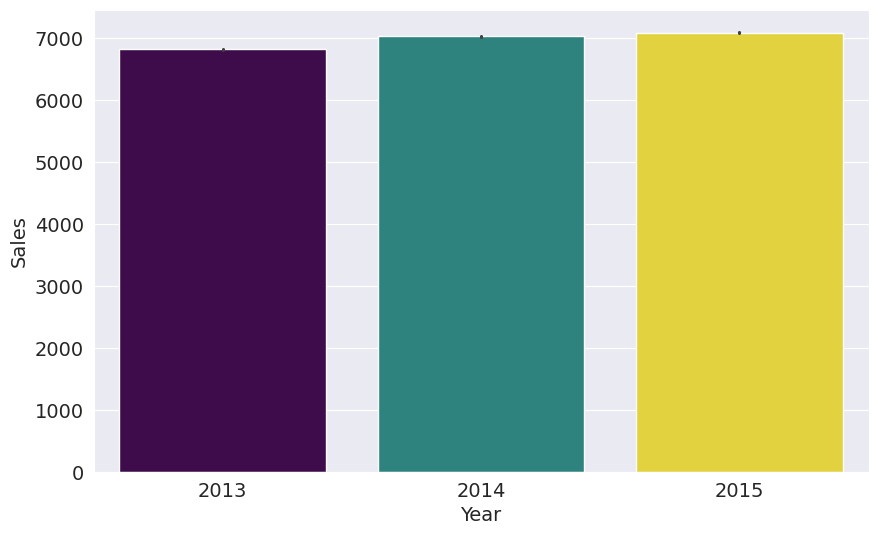

In [ ]:
sns.barplot(data=merged_df, x='Year', y='Sales', hue='Year', palette='viridis', legend=False)

/tmp/ipykernel_7855/2826761410.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=merged_df, x='Month', y='Sales', palette='viridis')


<Axes: xlabel='Month', ylabel='Sales'>

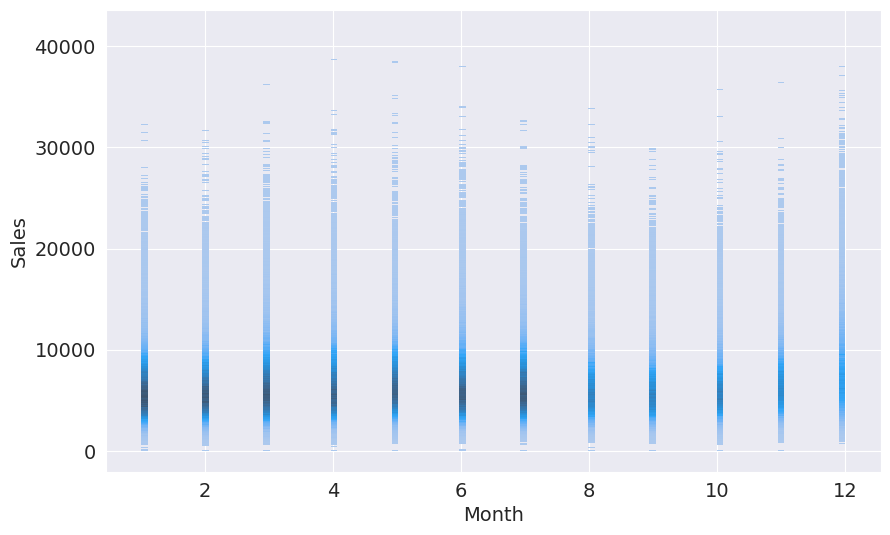

In [ ]:
sns.histplot(data=merged_df, x='Month', y='Sales', palette='viridis')

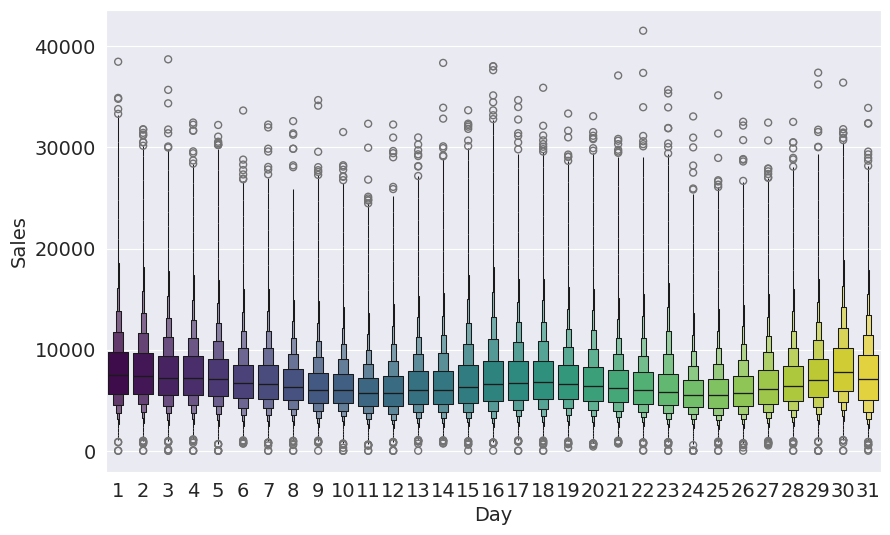

In [ ]:
sns.boxenplot(data=merged_df, x='Day', y='Sales', hue='Day', palette='viridis', legend=False);


It would be better if we'd known the day of the week (Monday, Tuesday,....), to know how the sales differ when the stores are open while there's a public holiday

In [ ]:
a=[merged_df['StateHoliday'] != '0']
a[0]

,StateHoliday
0,False
1,False
2,False
3,False
4,False
...,...
1016776,True
1016827,True
1016863,True
1017042,True


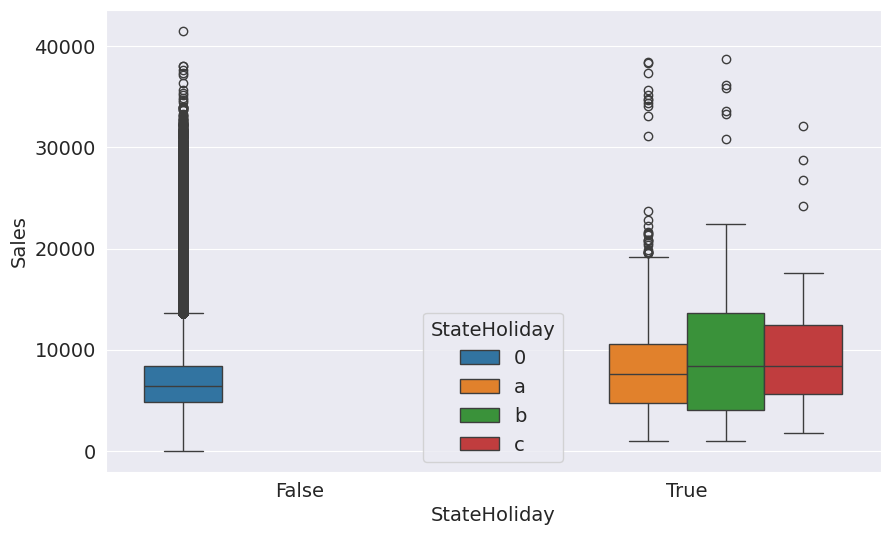

In [ ]:
sns.boxplot(data=merged_df, x=a[0], y='Sales',hue='StateHoliday',  legend=True);

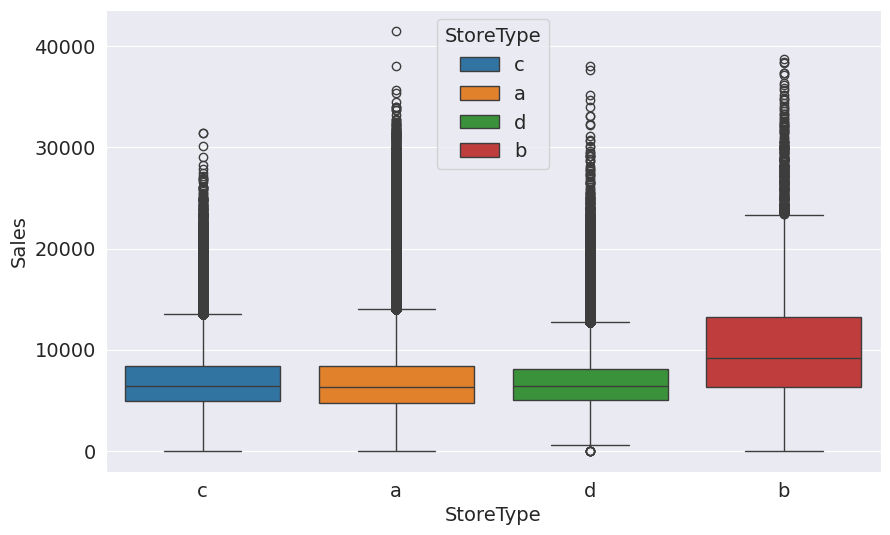

In [ ]:
sns.boxplot(data=merged_df, x='StoreType', y='Sales',hue='StoreType',  legend=True);

In [ ]:
merged_df[merged_df['StateHoliday'] != '0']['Sales']

,Sales
63559,5807
63560,5749
63609,5984
63611,9301
63614,10399
...,...
1016776,3375
1016827,10765
1016863,5035
1017042,4491


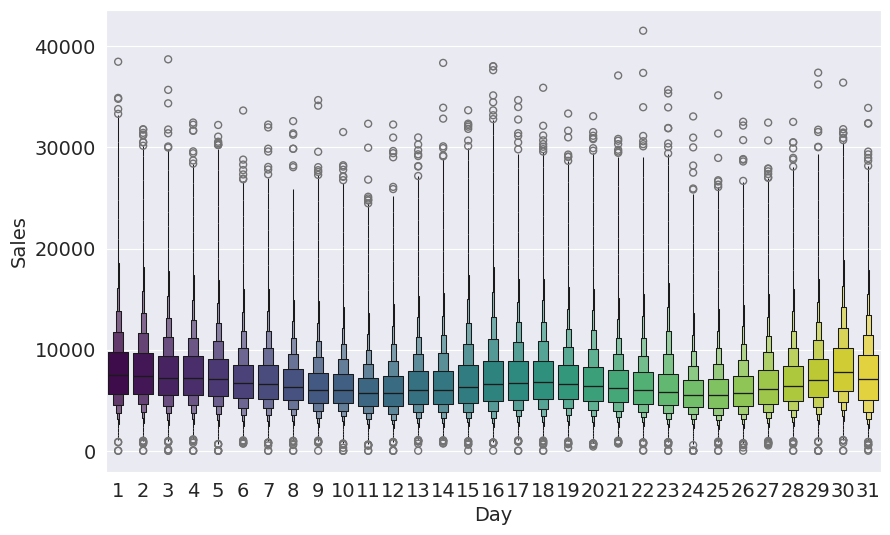

In [ ]:
sns.boxenplot(data=merged_df, x='Day', y='Sales', hue='Day', palette='viridis', legend=False);




Using date information, we can also create new current columns like:

1. Weather on each day
2. Whether the date was a public holiday
3. Whether the store was running a promotion on that day.



### Train/Test/Validation Split

The data already contains a test set, which contains over one month of data after the end of the training set. We can apply a similar strategy to create a validation set. We'll the last 25% of rows for the validation set, after ordering by date

In [ ]:
train_size = int(.85 * len(merged_df))
train_size

717733

In [ ]:
val_size=(len(merged_df)-train_size)
val_size

126659

In [ ]:
sorted_df = merged_df.sort_values('Date')
train_df, val_df = sorted_df[:train_size], sorted_df[train_size:]

In [ ]:
len(train_df), len(val_df)

(717733, 126659)

In [ ]:
train_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Day,Month,Year
1017190,1097,2,2013-01-01,5961,1405,1,0,a,1,b,...,720.0,3.0,2002.0,0,NaN,NaN,NaN,1,1,2013
1016179,85,2,2013-01-01,4220,619,1,0,a,1,b,...,1870.0,10.0,2011.0,0,NaN,NaN,NaN,1,1,2013
1016353,259,2,2013-01-01,6851,1444,1,0,a,1,b,...,210.0,NaN,NaN,0,NaN,NaN,NaN,1,1,2013
1016356,262,2,2013-01-01,17267,2875,1,0,a,1,b,...,1180.0,5.0,2013.0,0,NaN,NaN,NaN,1,1,2013
1016368,274,2,2013-01-01,3102,729,1,0,a,1,b,...,3640.0,NaN,NaN,1,10.0,2013.0,"Jan,Apr,Jul,Oct",1,1,2013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152893,139,1,2015-03-16,9073,670,1,1,0,0,a,...,1700.0,1.0,2008.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",16,3,2015
152994,240,1,2015-03-16,6422,576,1,1,0,0,a,...,1110.0,5.0,2009.0,0,NaN,NaN,NaN,16,3,2015
152993,239,1,2015-03-16,7631,665,1,1,0,0,d,...,610.0,NaN,NaN,0,NaN,NaN,NaN,16,3,2015
152992,238,1,2015-03-16,10368,1320,1,1,0,0,a,...,320.0,NaN,NaN,1,45.0,2009.0,"Feb,May,Aug,Nov",16,3,2015


In [ ]:
train_df.Date.min(), train_df.Date.max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2015-03-16 00:00:00'))

In [ ]:
val_df.Date.min(), val_df.Date.max()

(Timestamp('2015-03-16 00:00:00'), Timestamp('2015-07-31 00:00:00'))

In [ ]:
merged_test_df.Date.min(), merged_test_df.Date.max()

(Timestamp('2015-08-01 00:00:00'), Timestamp('2015-09-17 00:00:00'))

In [ ]:
train_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Day,Month,Year
1017190,1097,2,2013-01-01,5961,1405,1,0,a,1,b,...,720.0,3.0,2002.0,0,NaN,NaN,NaN,1,1,2013
1016179,85,2,2013-01-01,4220,619,1,0,a,1,b,...,1870.0,10.0,2011.0,0,NaN,NaN,NaN,1,1,2013
1016353,259,2,2013-01-01,6851,1444,1,0,a,1,b,...,210.0,NaN,NaN,0,NaN,NaN,NaN,1,1,2013
1016356,262,2,2013-01-01,17267,2875,1,0,a,1,b,...,1180.0,5.0,2013.0,0,NaN,NaN,NaN,1,1,2013
1016368,274,2,2013-01-01,3102,729,1,0,a,1,b,...,3640.0,NaN,NaN,1,10.0,2013.0,"Jan,Apr,Jul,Oct",1,1,2013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152893,139,1,2015-03-16,9073,670,1,1,0,0,a,...,1700.0,1.0,2008.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",16,3,2015
152994,240,1,2015-03-16,6422,576,1,1,0,0,a,...,1110.0,5.0,2009.0,0,NaN,NaN,NaN,16,3,2015
152993,239,1,2015-03-16,7631,665,1,1,0,0,d,...,610.0,NaN,NaN,0,NaN,NaN,NaN,16,3,2015
152992,238,1,2015-03-16,10368,1320,1,1,0,0,a,...,320.0,NaN,NaN,1,45.0,2009.0,"Feb,May,Aug,Nov",16,3,2015


### Input and Target columns

Let's also identify input and target columns. Note that we can't use the no. of customers as an input, because this information isn't available beforehand. Also, we needn't use all the available columns, we can start out with just a small subset.

In [ ]:
train_df['Store']

,Store
1017190,1097
1016179,85
1016353,259
1016356,262
1016368,274
...,...
152893,139
152994,240
152993,239
152992,238


In [ ]:
input_cols = ['Store', 'DayOfWeek', 'Promo', 'StateHoliday', 'StoreType', 'Assortment', 'Day', 'Month', 'Year']

In [ ]:
target_col = 'Sales'

Let's also separate out numeric and categorical columns.

In [ ]:
merged_df[input_cols].nunique()

,0
Store,1115
DayOfWeek,7
Promo,2
StateHoliday,4
StoreType,4
Assortment,3
Day,31
Month,12
Year,3


In [ ]:
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

In [ ]:
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

In [ ]:
test_inputs = merged_test_df[input_cols].copy()
# Test data does not have targets

In [ ]:
numeric_cols = ['Store', 'Day', 'Month', 'Year']
categorical_cols = ['DayOfWeek', 'Promo', 'StateHoliday', 'StoreType', 'Assortment']

### Imputation, Scaling and Encode

Let's impute missing data from numeric columns and scale the values to the $(0, 1)$ range.

In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
imputer = SimpleImputer(strategy='median').fit(train_inputs[numeric_cols])

In [ ]:
train_inputs[numeric_cols] = imputer.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = imputer.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = imputer.transform(test_inputs[numeric_cols])

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler().fit(train_inputs[numeric_cols])

In [ ]:
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = scaler.transform(test_inputs[numeric_cols])

Finally, let's encode categorical columns as one-hot vectors.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(train_inputs[categorical_cols])
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))
print(encoded_cols)

['DayOfWeek_1', 'DayOfWeek_2', 'DayOfWeek_3', 'DayOfWeek_4', 'DayOfWeek_5', 'DayOfWeek_6', 'DayOfWeek_7', 'Promo_0', 'Promo_1', 'StateHoliday_0', 'StateHoliday_a', 'StateHoliday_b', 'StateHoliday_c', 'StoreType_a', 'StoreType_b', 'StoreType_c', 'StoreType_d', 'Assortment_a', 'Assortment_b', 'Assortment_c']


In [ ]:
train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])
test_inputs[encoded_cols] = encoder.transform(test_inputs[categorical_cols])

In [ ]:
X_train = train_inputs[numeric_cols + encoded_cols]
X_val = val_inputs[numeric_cols + encoded_cols]
X_test = test_inputs[numeric_cols + encoded_cols]

## Create quick & easy baseline models to benchmark future models

<img src="https://i.imgur.com/1DLgiEz.png" width="640">

A quick baseline model helps establish the minimum score any ML model you train should achieve.


### Fixed/Random Guess

Let's define a model that always returns the mean value of Sales as the prediction.

In [ ]:
def return_mean(inputs):
    # Create an array of the same length as 'inputs'
    # Fill the array with the mean of the 'Sales' column from 'merged_df'
    return np.full(len(inputs), merged_df.Sales.mean())

In [ ]:
train_preds = return_mean(X_train)

In [ ]:
train_preds

array([6955.51429076, 6955.51429076, 6955.51429076, ..., 6955.51429076,
       6955.51429076, 6955.51429076])

Let's evaluate this to using the RMSE score.

In [ ]:
from sklearn.metrics import mean_squared_error

In [ ]:
np.sqrt(mean_squared_error(train_preds, train_targets))

np.float64(3098.2788177851357)

The model is off by about $3100 on average.

---

\
Let's try another model, which makes a random guess between the lowest and highest sale.

In [ ]:
def guess_random(inputs):
    lo, hi = merged_df.Sales.min(), merged_df.Sales.max()
    return np.random.random(len(inputs)) * (hi - lo) + lo

In [ ]:
train_preds = guess_random(X_train)
train_preds

array([39989.47389287,  7568.17009108, 35988.41525914, ...,
       29604.99990206,  3923.13194257,  7459.78980454])

In [ ]:
np.sqrt(mean_squared_error(train_preds, train_targets))

np.float64(18576.822622864518)

### Hand-coded Strategies

In [ ]:
# Pre-computation of average sales by Store, Month, and Year from the training data
average_sales_by_store_month_year = train_df.groupby(['Store', 'Month', 'Year'])['Sales'].mean().to_dict()

# Overall mean sales from the training data, used as a fallback for open stores if specific historical data is missing
overall_train_mean_sales = train_df.Sales.mean()

def predict_sales_strategy(row):
    """
    Predicts sales based on the defined strategy:
    - If the store is closed (Open == 0), return 0.
    - If the store is open (Open == 1):
      - Return the average sales for the store in the current month of the previous year.
      - If previous year's data is not available, return the overall mean sales from the training set.
    """
    if row['Open'] == 0:
        return 0
    else:
        store_id = row['Store']
        month = row['Month']
        current_year = row['Year']
        previous_year = current_year - 1

        key = (store_id, month, previous_year)
        if key in average_sales_by_store_month_year:
            return average_sales_by_store_month_year[key]
        else:
            return overall_train_mean_sales

# Apply the prediction strategy to the validation set
# Note: val_df only contains open stores due to previous filtering (merged_df = merged_df[merged_df['Open']==1].copy())
# Therefore, the 'if row['Open'] == 0' condition will not be met for val_df.
val_preds = val_df.apply(predict_sales_strategy, axis=1)

# Calculate the RMSE for the validation set
rmse_val_strategy = np.sqrt(mean_squared_error(val_preds, val_targets))
print(f"Validation Set RMSE for the custom strategy: {rmse_val_strategy:.2f}")

Validation Set RMSE for the custom strategy: 1999.60


Hand-coded Strategy outperformed other dumb strategies

### Baseline ML model

Let's train a simple `LinearRegression` model, with no customization.

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
linreg = LinearRegression()

In [ ]:
linreg.fit(X_train, train_targets)

LinearRegression()

In [ ]:
X_train.columns

Index(['Store', 'Day', 'Month', 'Year', 'DayOfWeek_1', 'DayOfWeek_2',
       'DayOfWeek_3', 'DayOfWeek_4', 'DayOfWeek_5', 'DayOfWeek_6',
       'DayOfWeek_7', 'Promo_0', 'Promo_1', 'StateHoliday_0', 'StateHoliday_a',
       'StateHoliday_b', 'StateHoliday_c', 'StoreType_a', 'StoreType_b',
       'StoreType_c', 'StoreType_d', 'Assortment_a', 'Assortment_b',
       'Assortment_c'],
      dtype='object')

In [ ]:
linreg.coef_

array([   96.52354688,   -53.77013104,   883.62750386,   312.26025749,
         981.47361212,  -102.42935105,  -456.99137902,  -434.77617124,
         -23.06465877,   -74.01205081,   109.79999877, -1127.86529749,
        1127.86529749,  -159.1974376 ,  -166.12112715,   -77.09985519,
         402.41841994, -1240.7194173 ,  4138.77613833, -1325.82723229,
       -1572.22948874,   887.33876397, -2541.93987424,  1654.60111027])

`model.fit` uses the following workflow for training the model ([source](https://www.deepnetts.com/blog/from-basic-machine-learning-to-deep-learning-in-5-minutes.html)):

1. We initialize a model with random parameters (weights & biases).
2. We pass some inputs into the model to obtain predictions.
3. We compare the model's predictions with the actual targets using the loss function.  
4. We use an optimization technique (like least squares, gradient descent etc.) to reduce the loss by adjusting the weights & biases of the model
5. We repeat steps 1 to 4 till the predictions from the model are good enough.


<img src="https://www.deepnetts.com/blog/wp-content/uploads/2019/02/SupervisedLearning.png" width="480">


In [ ]:
train_preds = linreg.predict(X_train)
train_preds

array([ 7030.6041333 , 10372.19710773,  6957.99485836, ...,
        9234.38928335,  8798.55036259,  8798.46371667])

In [ ]:
np.sqrt(mean_squared_error(train_preds, train_targets))

np.float64(2757.074606592519)

In [ ]:
val_preds = linreg.predict(X_val)
val_preds

array([8798.37707076, 8798.29042485, 8466.69370749, ..., 8814.70341941,
       8567.78128749, 7982.80322215])

In [ ]:
np.sqrt(mean_squared_error(val_preds, val_targets))

np.float64(2767.6853304254714)

Based on the above baselines, we now know that any model we train should have ideally have a RMSE score lower than $2800. This baseline can also be conveyed to other stakeholders to get a sense of whether the range of loss makes sense.


---

The linear regression model without parameter tuning outperformed other dumb (That always predicted mean) model, but not the hand modeled strategy. We'll now try to outperform the other models through hyperparameter tuning.


## Pick a strategy, train a model & tune hyperparameters

<img src="https://i.imgur.com/aRuE5mw.png" width="640">


# Systematically Exploring Modeling Strategies

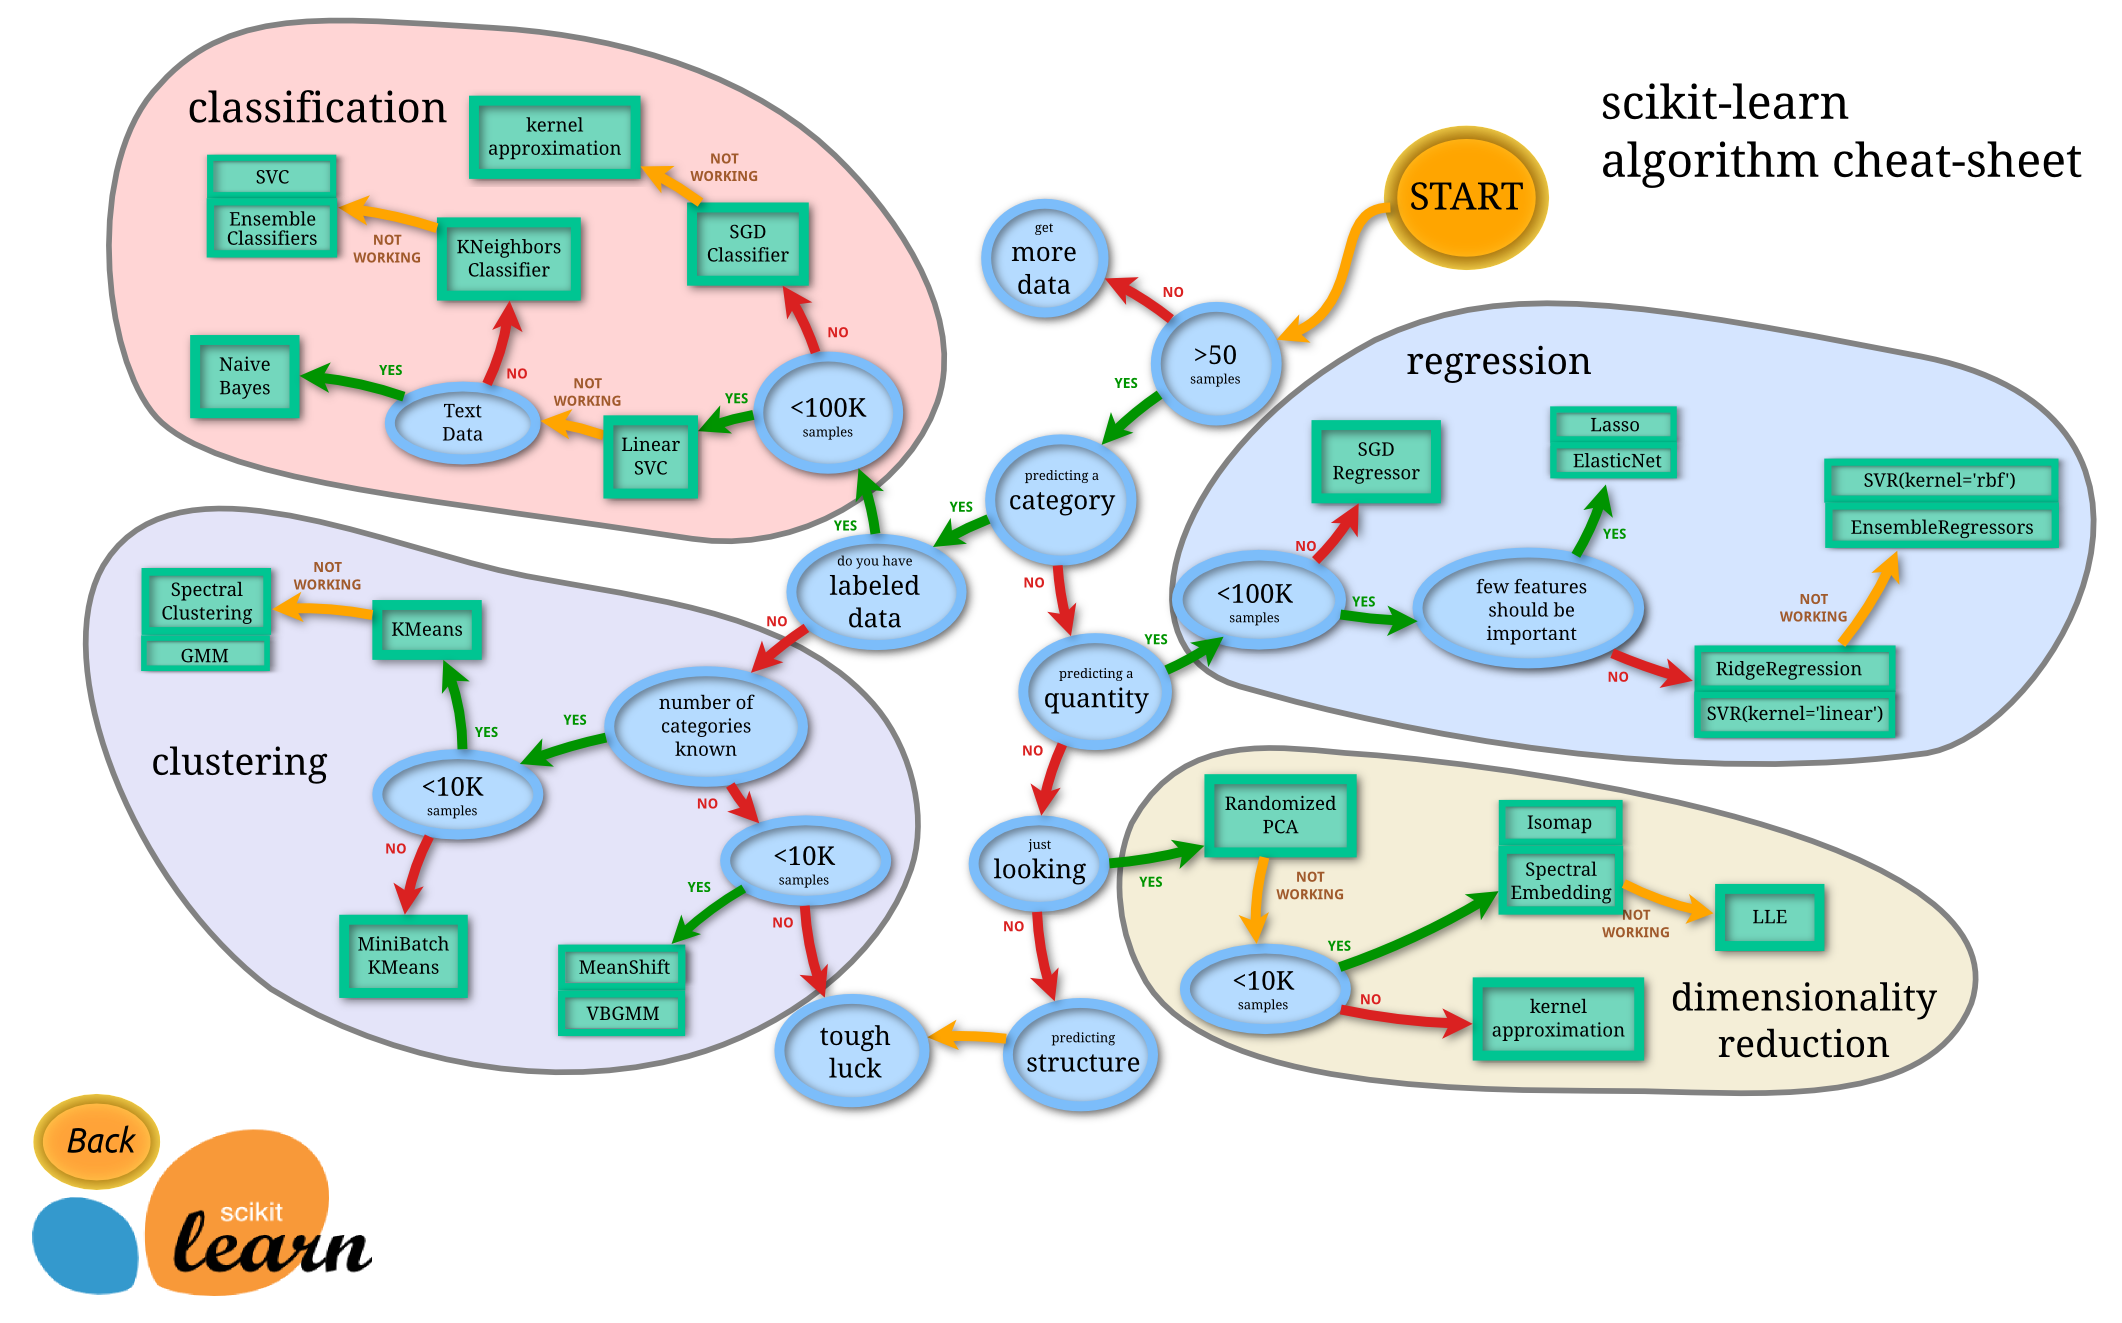

Here's the general strategy to follow:

- Find out which models are applicable to the problem you're solving.
- Train a basic version for each type of model that's applicable
- Identify the modeling approaches that work well and tune their hypeparameters
- Use a spreadsheetto keep track of your experiments and results.

In [ ]:
#Let's define a function `try_model`, which takes a model, then performs training and evaluation.
def try_model(model):
    # Fit the model
    model.fit(X_train, train_targets)

    # Generate predictions
    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)

    # Compute RMSE
    train_rmse = np.sqrt(mean_squared_error(train_targets, train_preds))
    val_rmse = np.sqrt(mean_squared_error(val_targets, val_preds))
    return train_rmse, val_rmse

### Linear Models


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor

In [ ]:
try_model(LinearRegression())

(np.float64(2757.074606592519), np.float64(2767.6853304254714))

In [ ]:
try_model(Ridge())

(np.float64(2757.0746092299096), np.float64(2767.684314876473))

In [ ]:
try_model(Lasso())

(np.float64(2757.2256655521255), np.float64(2767.516057259681))

In [ ]:
try_model(ElasticNet())

(np.float64(2898.3501364165727), np.float64(2928.053913059478))

In [ ]:
try_model(SGDRegressor())

(np.float64(2757.648292075636), np.float64(2770.693724857804))

The above base linear models performed as bad or worse than the dumber models, we can proceed with improving hyperparameters

### Tree Based Models


In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

In [ ]:
tree = DecisionTreeRegressor(random_state=42)
try_model(tree)

(np.float64(0.0), np.float64(1476.3953800070278))

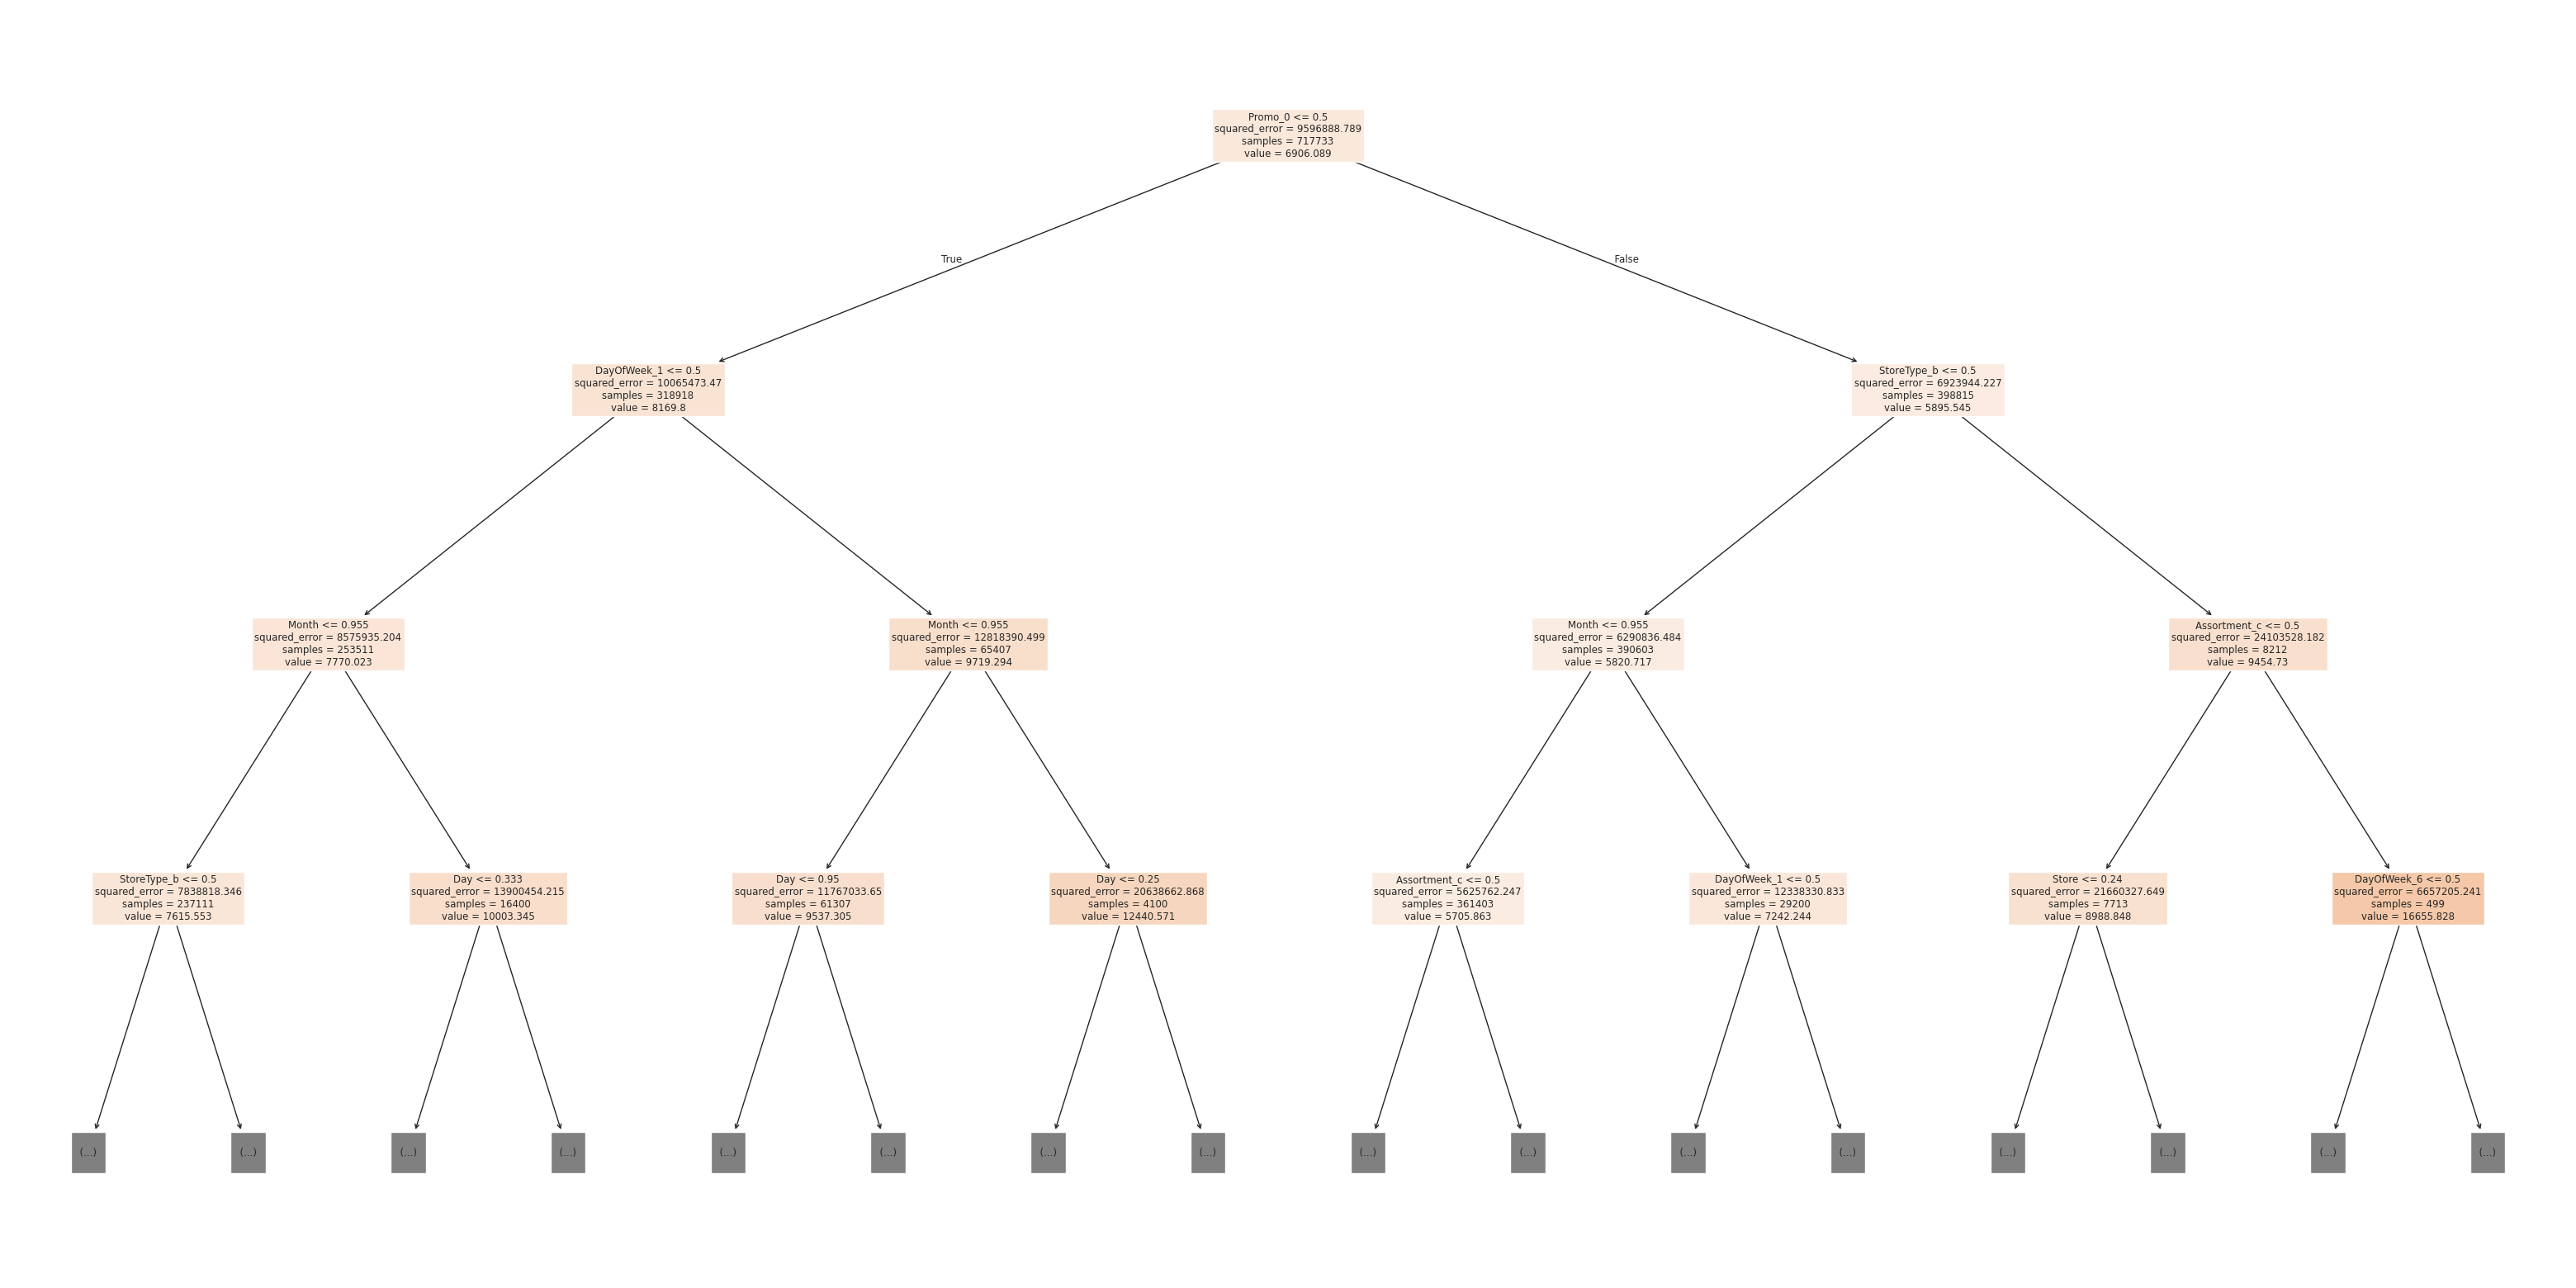

In [ ]:
plt.figure(figsize=(40, 20))
plot_tree(tree, max_depth=3, filled=True, feature_names=numeric_cols+encoded_cols);

Let's try a random forest.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf.fit(X_train, train_targets)

RandomForestRegressor(n_jobs=-1, random_state=42)

## Experiment and combine results from multiple strategies

<img src="https://i.imgur.com/ZqM6R8w.png" width="640">

### Hyperparameter Optimization & Grid Search

You can tune hyperparameters manually, our use an automated tuning strategy like random search or Grid search. Follow this tutorial for hyperparameter tuning using Grid search: https://machinelearningmastery.com/hyperparameter-optimization-with-random-search-and-grid-search/

<img src="https://i.imgur.com/EJCrSZw.png" width="480">

In general, the following strategies can be used to improve the performance of a model:

- Gather more data. A greater amount of data can let you learn more relationships and generalize the model better.
- Include more features. The more relevant the features for predicting the target, the better the model gets.
- Tune the hyperparameters of the model. Increase the capacity of the model while ensuring that it doesn't overfit.
- Look at the specific examples where the model make incorrect or bad predictions and gather some insights
- Try strategies like grid search for hyperparameter optimization and K-fold cross validation
- Combine results from different types of models (ensembling), or train another model using their results.

# Experenting tuning hyperparametes with GridSearch
Apply grid search to find the best hyperparameters for the random forest regressor trained earlier.

In [ ]:
pip install opendatasets --quiet

In [ ]:
# from sklearn.model_selection import GridSearchCV
# from sklearn.ensemble import RandomForestRegressor

# param_grid = {
#     'n_estimators': [100, 200],
#     'max_features': [0.7, 0.8],
#     'min_samples_leaf': [5, 10]
# }

# rf = RandomForestRegressor(random_state=42, n_jobs=20)
# grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
#                            cv=3, n_jobs=-1, verbose=2, scoring='neg_root_mean_squared_error')

# %time grid_search.fit(X_train, train_targets)

# print("Best parameters found: ", grid_search.best_params_)
# print("Best RMSE found: ", -grid_search.best_score_)

In [ ]:
# best_rf_model = grid_search.best_estimator_

# # Evaluate on validation set
# val_preds_tuned = best_rf_model.predict(X_val)
# val_rmse_tuned = np.sqrt(mean_squared_error(val_targets, val_preds_tuned))

# # Evaluate on test set (predictions only as there are no test targets)
# test_preds_tuned = best_rf_model.predict(X_test)

# print(f"Validation RMSE with tuned model: {val_rmse_tuned:.2f}")

# # For the test set, we can only generate predictions, not compute RMSE without targets
# print("Predictions for the test set have been generated and stored in 'test_preds_tuned'.")

### Ensembling and Stacking

Ensembling refers to combining the results of multiple models. Here's what ensembling looks like visually([source](https://www.kdnuggets.com/2019/01/ensemble-learning-5-main-approaches.html)):

<img src="https://i.imgur.com/rrOKVEd.png" width="480">


Stacking is a more advanced version of ensembling, where we train another model using the results from multiple models. Here's what stacking looks like visually ([source](https://medium.com/ml-research-lab/stacking-ensemble-meta-algorithms-for-improve-predictions-f4b4cf3b9237)):

<img src="https://i.imgur.com/VVzCWNB.png" width="400">

Here's a tutorial on stacking: https://machinelearningmastery.com/stacking-ensemble-machine-learning-with-python/

---

## FINAL STEP &rarr; Interpret models, study individual predictions & present your findings

<img src="https://i.imgur.com/9axhOrA.png" width="640">

### Feature Importance
 Most scikit-learn models offer some kind of "feature importance" score.

In [ ]:
importance_df = pd.DataFrame({
    'feature': numeric_cols+encoded_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
importance_df.head(10)

,feature,importance
0,Store,0.602385
12,Promo_1,0.077127
11,Promo_0,0.055862
2,Month,0.053057
1,Day,0.052331
4,DayOfWeek_1,0.034150
18,StoreType_b,0.022892
17,StoreType_a,0.013654
20,StoreType_d,0.013488
3,Year,0.013055


In [ ]:
importance_df = pd.DataFrame({
    'feature': numeric_cols+encoded_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
importance_df.head(10)

,feature,importance
0,Store,0.602385
12,Promo_1,0.077127
11,Promo_0,0.055862
2,Month,0.053057
1,Day,0.052331
4,DayOfWeek_1,0.034150
18,StoreType_b,0.022892
17,StoreType_a,0.013654
20,StoreType_d,0.013488
3,Year,0.013055


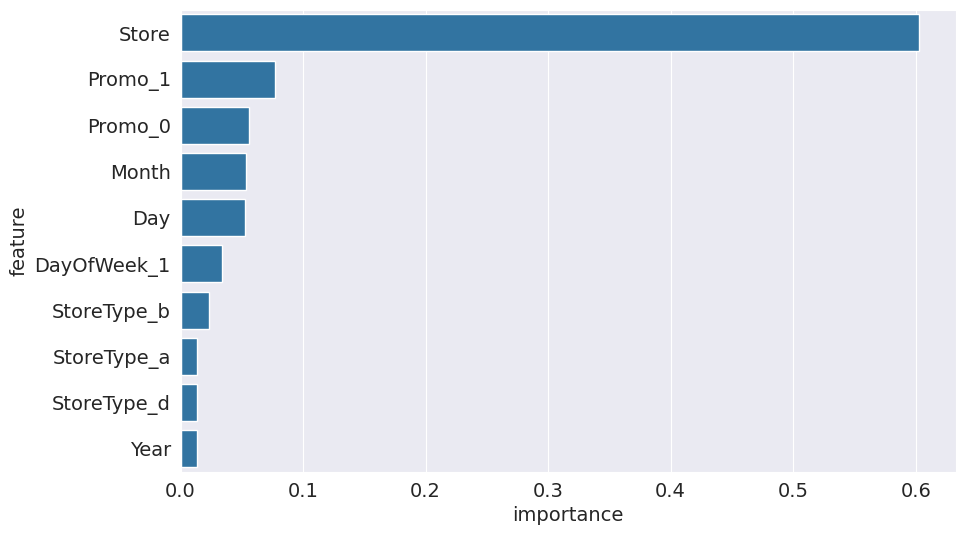

In [ ]:
sns.barplot(data=importance_df.head(10), x='importance', y='feature');

The above chart can be presented to non-technical stakeholders to explain how the model arrives at its result. For greater explainability, a single decision tree can be used.

In [ ]:
def predict_input(model, single_input):
    if single_input['Open'] == 0:
        return 0.
    input_df = pd.DataFrame([single_input])
    input_df['Date'] = pd.to_datetime(input_df.Date)
    input_df['Day'] = input_df.Date.dt.day
    input_df['Month'] = input_df.Date.dt.month
    input_df['Year'] = input_df.Date.dt.year
    input_df[numeric_cols] = imputer.transform(input_df[numeric_cols])
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])
    input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
    X_input = input_df[numeric_cols + encoded_cols]
    pred = model.predict(X_input)[0]
    return pred

In [ ]:
sample_input = {'Id': 1,
 'Store': 1,
 'DayOfWeek': 4,
 'Date': '2015-09-17 00:00:00',
 'Open': 1.0,
 'Promo': 1,
 'StateHoliday': '0',
 'SchoolHoliday': 0,
 'StoreType': 'c',
 'Assortment': 'a',
 'CompetitionDistance': 1270.0,
 'CompetitionOpenSinceMonth': 9.0,
 'CompetitionOpenSinceYear': 2008.0,
 'Promo2': 0,
 'Promo2SinceWeek': np.nan,
 'Promo2SinceYear': np.nan,
 'PromoInterval': np.nan}

sample_input

{'Id': 1,
 'Store': 1,
 'DayOfWeek': 4,
 'Date': '2015-09-17 00:00:00',
 'Open': 1.0,
 'Promo': 1,
 'StateHoliday': '0',
 'SchoolHoliday': 0,
 'StoreType': 'c',
 'Assortment': 'a',
 'CompetitionDistance': 1270.0,
 'CompetitionOpenSinceMonth': 9.0,
 'CompetitionOpenSinceYear': 2008.0,
 'Promo2': 0,
 'Promo2SinceWeek': nan,
 'Promo2SinceYear': nan,
 'PromoInterval': nan}

In [ ]:
predict_input(best_rf_model, sample_input)

np.float64(4427.538875945951)

### Presenting The Results

* Create a presentation for non-technical stakeholders
* Understand your audience - figure out what they care about most
* Avoid showing any code or technical jargon, include visualizations
* Focus on metrics that are relevant for the business
* Talk about feature importance and how to interpret results
* Explain the strengths and limitations of the model
* Explain how the model can be improved over time

In [ ]:
test_preds = rf.predict(X_test)
test_preds

array([ 4241.08,  7590.22,  8692.15, ...,  6076.79, 20637.77,  7128.88])

In [ ]:
submission_df = pd.read_csv('/content/sample_submission.csv')

In [ ]:
submission_df['Sales'] = test_preds * test_df['Open'].astype('float')

In [ ]:
submission_df.fillna(0, inplace=True)

In [ ]:
submission_df.to_csv('submission.csv', index=None)

In [ ]:
!head submission.csv

Id,Sales
1,4241.08
2,7590.22
3,8692.15
4,7382.93
5,7018.64
6,5743.96
7,8173.55
8,8280.69
9,5863.56


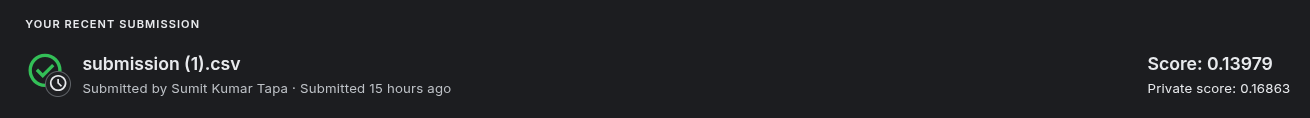